In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

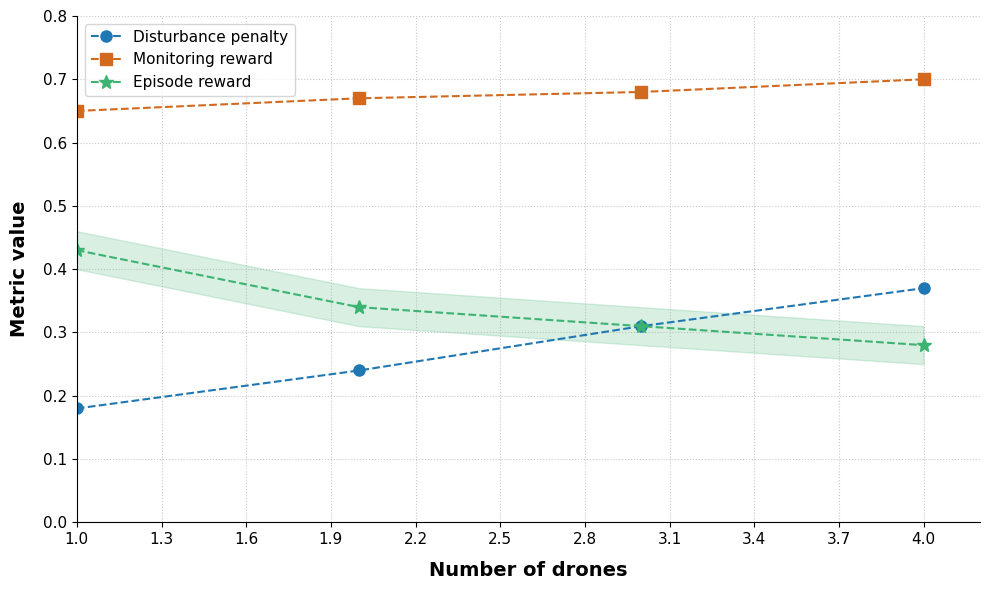

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Setup ---
# Mimicking the values from your original plot
x = np.array([1, 2, 3, 4])
dist_penalty = np.array([0.18, 0.24, 0.31, 0.37])
monit_reward = np.array([0.65, 0.67, 0.68, 0.70])
ep_reward = np.array([0.43, 0.34, 0.31, 0.28])
std_dev = 0.03 # For the shaded area

fig, ax = plt.subplots(figsize=(10, 6))

# --- 2. Plotting ---
ax.plot(x, dist_penalty, '--o', label='Disturbance penalty', markersize=8)
ax.plot(x, monit_reward, '--s', label='Monitoring reward', color='chocolate', markersize=8)
ax.plot(x, ep_reward, '--*', label='Episode reward', color='mediumseagreen', markersize=10)

# Shaded error range
ax.fill_between(x, ep_reward - std_dev, ep_reward + std_dev, color='mediumseagreen', alpha=0.2)

# --- 3. Fixing the Problems Highlighted ---

# 11 values on X-axis and tight range so grid hits the edges
ax.set_xticks(np.linspace(1, 4, 11))
ax.set_xlim(1, 4.2)

# Better Y range (starting at 0 for context)
ax.set_ylim(0, 0.8)

# Remove right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Grid spanning the full plot area
ax.grid(True, linestyle=':', alpha=0.7)

# --- 4. Styling (Bold and Larger Labels) ---
ax.set_xlabel('Number of drones', fontweight='bold', fontsize=14, labelpad=10)
ax.set_ylabel('Metric value', fontweight='bold', fontsize=14, labelpad=10)

# Make tick numbers slightly larger for readability
ax.tick_params(axis='both', which='major', labelsize=11)

# Legend placement in an empty area to avoid overlapping data
ax.legend(loc='upper left', fontsize=11, frameon=True)

plt.tight_layout()
plt.savefig("../../figures/mappo.png", dpi=300)
plt.show()

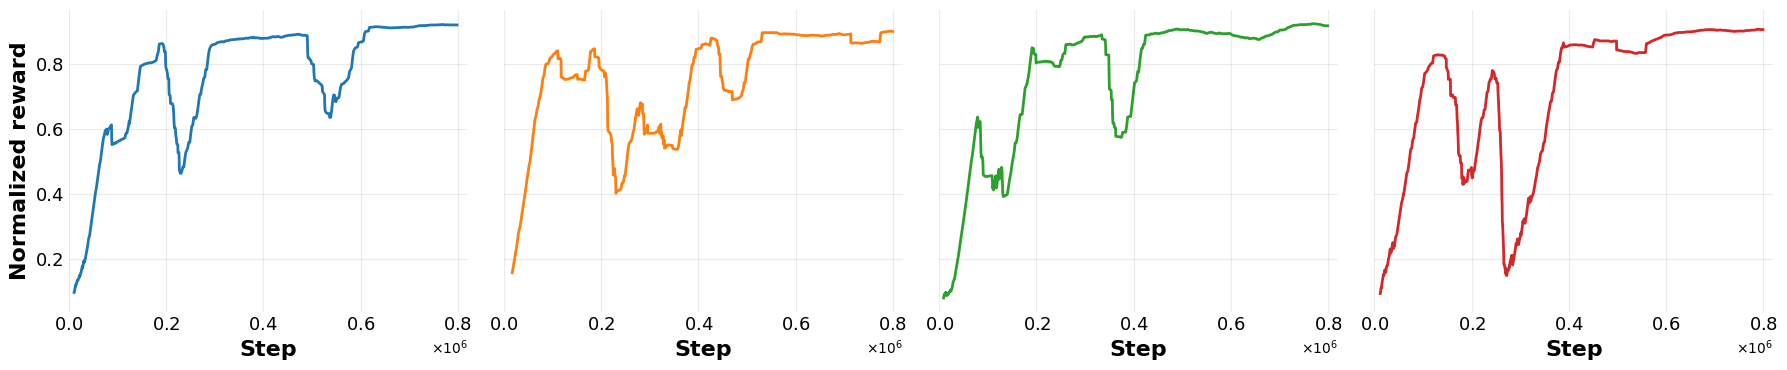

In [18]:
def rolling_mean_xy(steps, values, w=100):
    steps = np.asarray(steps, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = ~np.isnan(steps) & ~np.isnan(values)
    steps = steps[mask]
    values = values[mask]

    if len(values) < 2:
        return steps, values

    w = min(w, len(values)//4 if len(values) > 20 else len(values))

    if w < 2:
        return steps, values

    y = np.convolve(values, np.ones(w) / w, mode="valid")
    x = steps[w - 1:]

    return x, y


# -----------------------------
# load data
# -----------------------------
crw_df = pd.read_csv("CRW_episode.csv")
ee_df = pd.read_csv("EE_episode.csv")
poi_df = pd.read_csv("POI_episode.csv")
lpoi_df = pd.read_csv("LPOI_episode.csv")

col_to_plot = "episode_reward_norm"
step_col = "step"

data = [
    (crw_df[step_col],  crw_df[col_to_plot],  "CRW"),
    (ee_df[step_col],   ee_df[col_to_plot],   "EE"),
    (poi_df[step_col],  poi_df[col_to_plot],  "POI"),
    (lpoi_df[step_col], lpoi_df[col_to_plot], "LPOI"),
]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# -----------------------------
# style
# -----------------------------
TITLE_FSIZE = 16
LABEL_FSIZE = 16
TICK_FSIZE = 13
LINEWIDTH = 2.0

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)

for ax, (steps, rews, short_title), color in zip(axes, data, colors):
    xs, ys = rolling_mean_xy(steps, rews, w=30)

    ax.plot(xs, ys, color=color, linewidth=LINEWIDTH)

    # titles
    # ax.set_title(short_title, fontsize=TITLE_FSIZE, fontweight="bold")

    # labels
    ax.set_xlabel("Step", fontsize=LABEL_FSIZE, fontweight="bold")

    # grid
    ax.grid(alpha=0.25)

    # remove border / box
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # ticks
    ax.tick_params(axis="both", labelsize=TICK_FSIZE, length=0)

    # scientific notation as 10^6 instead of e6
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((6, 6))  # force 10^6 scale
    ax.xaxis.set_major_formatter(formatter)

    # x limits 0 to 2e6
    ax.set_xlim(0, 8.2e5)

    # fewer ticks
    ax.locator_params(axis="x", nbins=5)

axes[0].set_ylabel("Normalized reward", fontsize=LABEL_FSIZE, fontweight="bold")

plt.tight_layout()
plt.savefig("../../figures/rews.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()

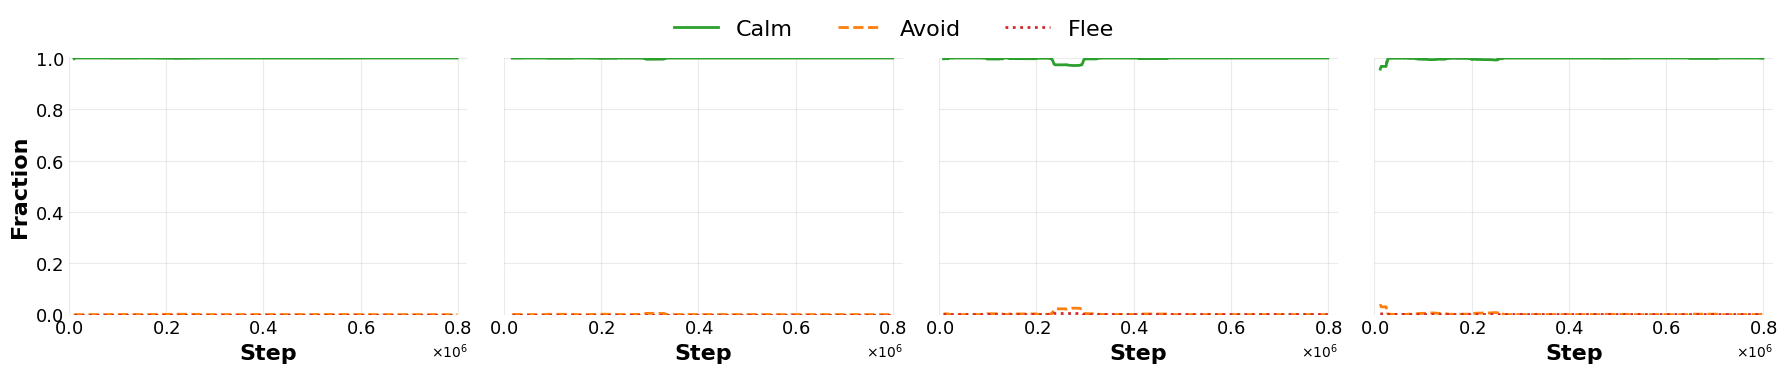

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


# reuse your smoothing
def rolling_mean_xy(steps, values, w=100):
    steps = np.asarray(steps, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = ~np.isnan(steps) & ~np.isnan(values)
    steps = steps[mask]
    values = values[mask]

    if len(values) < 2:
        return steps, values

    w = min(w, len(values)//4 if len(values) > 20 else len(values))

    if w < 2:
        return steps, values

    y = np.convolve(values, np.ones(w)/w, mode="valid")
    x = steps[w-1:]

    return x, y


# -----------------------------
# load data
# -----------------------------
crw_df = pd.read_csv("CRW_episode.csv")
ee_df = pd.read_csv("EE_episode.csv")
poi_df = pd.read_csv("POI_episode.csv")
lpoi_df = pd.read_csv("LPOI_episode.csv")

step_col = "step"
fractions = ["calm_frac", "avoid_frac", "flee_frac"]

data = [
    (crw_df, "CRW"),
    (ee_df, "EE"),
    (poi_df, "POI"),
    (lpoi_df, "LPOI"),
]

colors = {
    "calm_frac": "tab:green",
    "avoid_frac": "tab:orange",
    "flee_frac": "tab:red",
}

linestyles = {
    "calm_frac": "-",
    "avoid_frac": "--",
    "flee_frac": ":",
}

labels = {
    "calm_frac": "Calm",
    "avoid_frac": "Avoid",
    "flee_frac": "Flee",
}


# -----------------------------
# style
# -----------------------------
TITLE_FSIZE = 16
LABEL_FSIZE = 16
TICK_FSIZE = 13
LINEWIDTH = 2.0


fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=True)

for ax, (df, short_title) in zip(axes, data):

    for frac in fractions:
        xs, ys = rolling_mean_xy(df[step_col], df[frac], w=30)

        ax.plot(
            xs,
            ys,
            color=colors[frac],
            linestyle=linestyles[frac],
            linewidth=LINEWIDTH,
            label=labels[frac],
        )

    # titles
    # ax.set_title(short_title, fontsize=TITLE_FSIZE, fontweight="bold")

    # labels
    ax.set_xlabel("Step", fontsize=LABEL_FSIZE, fontweight="bold")

    # limits
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 8.2e5)

    # grid
    ax.grid(alpha=0.25)

    # remove borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # ticks
    ax.tick_params(axis="both", labelsize=TICK_FSIZE, length=0)

    # scientific 10^6 notation
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((6, 6))
    ax.xaxis.set_major_formatter(formatter)

    # fewer ticks
    ax.locator_params(axis="x", nbins=5)

axes[0].set_ylabel("Fraction", fontsize=LABEL_FSIZE, fontweight="bold")


# single legend
handles, legend_labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=LABEL_FSIZE
)


plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.savefig(
    "../../figures/behavior_fractions_by_dataset.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

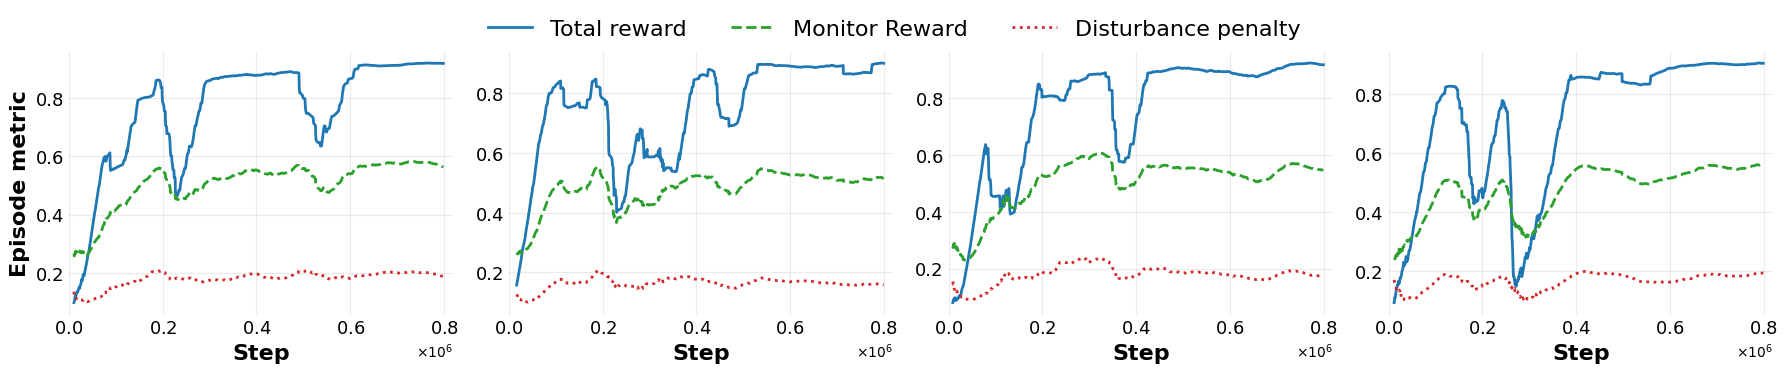

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


# reuse smoothing
def rolling_mean_xy(steps, values, w=100):
    steps = np.asarray(steps, dtype=float)
    values = np.asarray(values, dtype=float)

    mask = ~np.isnan(steps) & ~np.isnan(values)
    steps = steps[mask]
    values = values[mask]

    if len(values) < 2:
        return steps, values

    w = min(w, len(values)//4 if len(values) > 20 else len(values))

    if w < 2:
        return steps, values

    y = np.convolve(values, np.ones(w)/w, mode="valid")
    x = steps[w-1:]

    return x, y


# -----------------------------
# load data
# -----------------------------
crw_df = pd.read_csv("CRW_episode.csv")
ee_df = pd.read_csv("EE_episode.csv")
poi_df = pd.read_csv("POI_episode.csv")
lpoi_df = pd.read_csv("LPOI_episode.csv")

step_col = "step"

metrics = [
    "episode_reward_norm",
    "r_dist",
    "p_disturbance",
]

data = [
    (crw_df, "CRW"),
    (ee_df, "EE"),
    (poi_df, "POI"),
    (lpoi_df, "LPOI"),
]

colors = {
    "episode_reward_norm": "tab:blue",
    "r_dist": "tab:green",
    "p_disturbance": "tab:red",
}

linestyles = {
    "episode_reward_norm": "-",
    "r_dist": "--",
    "p_disturbance": ":",
}

labels = {
    "episode_reward_norm": "Total reward",
    "r_dist": "Monitor Reward",
    "p_disturbance": "Disturbance penalty",
}


# -----------------------------
# style
# -----------------------------
TITLE_FSIZE = 16
LABEL_FSIZE = 16
TICK_FSIZE = 13
LINEWIDTH = 2.0


fig, axes = plt.subplots(1, 4, figsize=(18, 3.8), sharey=False)

for ax, (df, short_title) in zip(axes, data):

    for metric in metrics:
        xs, ys = rolling_mean_xy(df[step_col], df[metric], w=30)

        if "r_dist" == metric:
            ys += 1
        ax.plot(
            xs,
            ys ,
            color=colors[metric],
            linestyle=linestyles[metric],
            linewidth=LINEWIDTH,
            label=labels[metric],
        )

    # titles
    # ax.set_title(short_title, fontsize=TITLE_FSIZE, fontweight="bold")

    # labels
    ax.set_xlabel("Step", fontsize=LABEL_FSIZE, fontweight="bold")

    # grid
    ax.grid(alpha=0.25)

    # x limits
    ax.set_xlim(0, 8.2e5)

    # remove borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)

    # ticks
    ax.tick_params(axis="both", labelsize=TICK_FSIZE, length=0)

    # scientific 10^6 notation
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((6, 6))
    ax.xaxis.set_major_formatter(formatter)

    # fewer ticks
    ax.locator_params(axis="x", nbins=5)


axes[0].set_ylabel(
    "Episode metric",
    fontsize=LABEL_FSIZE,
    fontweight="bold"
)


# shared legend
handles, legend_labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=LABEL_FSIZE
)


plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.savefig(
    "../../figures/reward_components_by_dataset.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

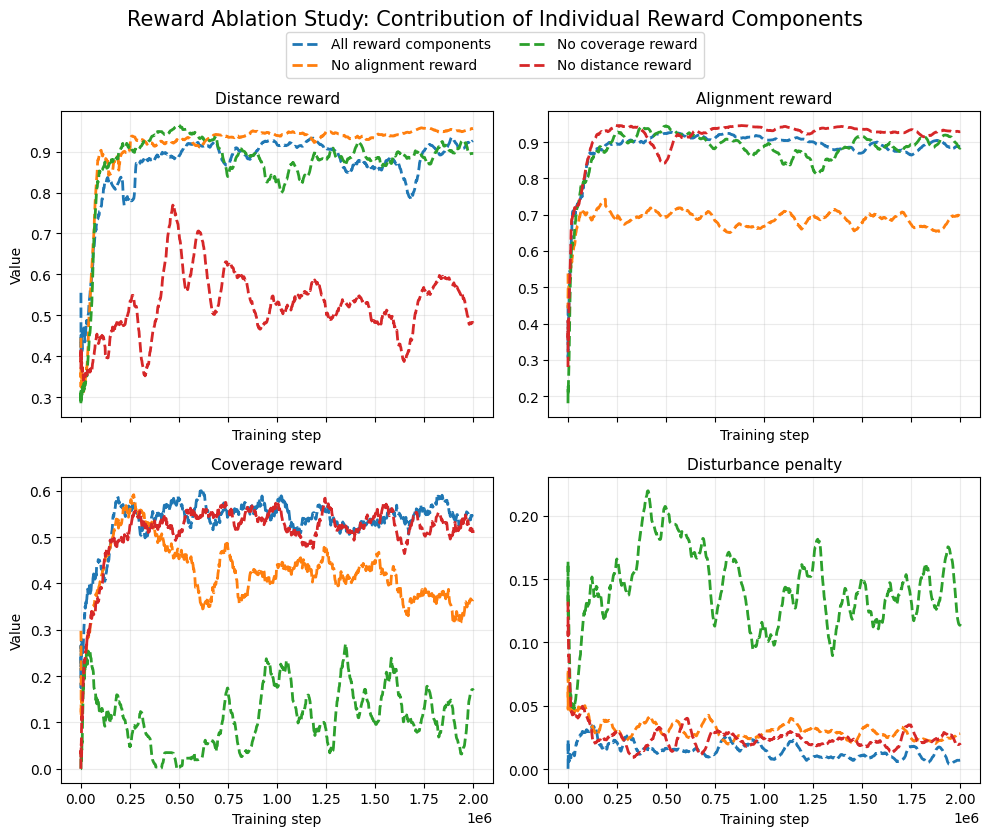

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# helper
# ----------------------------
def rolling_mean_xy(x, y, w=30):
    x = pd.Series(x).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    y_smooth = y.rolling(window=w, min_periods=1).mean()
    return x, y_smooth

# ----------------------------
# load data
# ----------------------------
crw_df = pd.read_csv("all_rew_comps.csv")
ee_df = pd.read_csv("no_align.csv")
poi_df = pd.read_csv("no_cover.csv")
lpoi_df = pd.read_csv("no_distance.csv")

step_col = "step"

runs = [
    (crw_df, "All reward components", "tab:blue"),
    (ee_df, "No alignment reward", "tab:orange"),
    (poi_df, "No coverage reward", "tab:green"),
    (lpoi_df, "No distance reward", "tab:red"),
]

columns = [
    "r_dist",
    "r_align",
    "r_bucket",
    "p_disturbance",
]

titles = {
    "r_dist": "Distance reward",
    "r_align": "Alignment reward",
    "r_bucket": "Coverage reward",
    "p_disturbance": "Disturbance penalty",
}

# ----------------------------
# plotting
# ----------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)

for ax, col in zip(axes.flatten(), columns):

    for df, label, color in runs:
        if col in df.columns:
            xs, ys = rolling_mean_xy(df[step_col], df[col], w=30)

            ax.plot(
                xs,
                ys,
                linestyle="--",
                linewidth=2,
                color=color,
                label=label
            )

    ax.set_title(titles[col], fontsize=11)
    ax.set_xlabel("Training step")
    ax.grid(alpha=0.25)

# y-labels only on left column
for i in range(2):
    axes[i,0].set_ylabel("Value")

# single legend
handles, labels = axes[0,0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Reward Ablation Study: Contribution of Individual Reward Components",
    fontsize=15,
    y=1.04,
)

plt.tight_layout()
plt.savefig("../../figures/reward_ablation_all_terms.png", dpi=300, bbox_inches="tight")
plt.show()